# 🔍 Machine Sensor Clustering & Anomaly Detection with SAP HANA & Python

**Author:** Sanusi Isiaka Olatunji

**Dataset:** Simulated IoT Machine Sensor Data  
**Database:** SAP HANA Cloud  
**Models:** KMeans Clustering, Isolation Forest, Z-Score Anomaly Detection  

## 📌 Project Overview
This project groups machines into risk clusters and detects anomalous sensor readings using SAP HANA Cloud:
1. Generate & upload IoT sensor data to HANA
2. Explore sensor distributions
3. Cluster machines into risk groups (KMeans)
4. Detect anomalies (Isolation Forest + Z-Score)
5. Visualize risk map
6. Save results to HANA

## ⚙️ Step 1: Install Dependencies

In [1]:
!pip install hdbcli==2.21.28 hana_ml scikit-learn matplotlib seaborn pandas numpy -q
print('✅ All packages installed!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 47.1 MB/s eta 0:00:00
✅ All packages installed!


## 🔌 Step 2: Connect to SAP HANA Cloud

In [3]:
from hana_ml import dataframe
from google.colab import userdata

HANA_ADDRESS = 'c9d016d3-0ed9-4852-9c5e-0604ee4c3e6d.hna1.prod-us10.hanacloud.ondemand.com'
HANA_PORT    = 443
HANA_USER    = 'DBADMIN'
HANA_SCHEMA  = 'ML_DEMO'

conn = dataframe.ConnectionContext(
    address=HANA_ADDRESS, port=HANA_PORT, user=HANA_USER,
    password=userdata.get('HANA_PASSWORD'),
    encrypt=True, sslValidateCertificate=False
)
if conn.connection.isconnected():
    print('✅ Connected to SAP HANA Cloud!')
    print(f'   Version: {conn.hana_version()}')

✅ Connected to SAP HANA Cloud!
   Version: 4.00.000.00.1777375411 (fa/CE2026.2)


## 📦 Step 3: Generate IoT Sensor Data & Upload to HANA

In [4]:
import pandas as pd
import numpy as np
from hana_ml.dataframe import create_dataframe_from_pandas

np.random.seed(42)
n = 2000

# Normal machines
normal = pd.DataFrame({
    'MachineID'  : [f'M_{i:04d}' for i in range(1, n+1)],
    'Temperature': np.random.normal(65, 8, n),
    'Vibration'  : np.random.normal(0.4, 0.1, n),
    'Pressure'   : np.random.normal(100, 10, n),
    'RPM'        : np.random.normal(1500, 150, n),
    'PowerUsage' : np.random.normal(200, 30, n),
    'OperatingHours': np.random.randint(100, 5000, n)
})

# Inject anomalies (5%)
anomaly_idx = np.random.choice(n, int(n * 0.05), replace=False)
normal.loc[anomaly_idx, 'Temperature'] += np.random.uniform(30, 60, len(anomaly_idx))
normal.loc[anomaly_idx, 'Vibration']   += np.random.uniform(0.5, 1.5, len(anomaly_idx))
normal.loc[anomaly_idx, 'Pressure']    += np.random.uniform(40, 80, len(anomaly_idx))

df = normal.round(3)
print(f'✅ Dataset: {len(df):,} machines | {len(anomaly_idx)} injected anomalies')
df.head()

✅ Dataset: 2,000 machines | 100 injected anomalies


,MachineID,Temperature,Vibration,Pressure,RPM,PowerUsage,OperatingHours
0,M_0001,68.974,0.332,91.365,1332.888,199.009,1997
1,M_0002,63.894,0.386,99.688,1405.360,184.890,1797
2,M_0003,70.182,0.321,100.180,1358.691,194.829,2914
3,M_0004,77.184,0.369,104.726,1417.801,221.442,3465
4,M_0005,63.127,0.211,86.331,1467.877,238.336,2588


In [5]:
cursor = conn.connection.cursor()
try:
    cursor.execute('CREATE SCHEMA ML_DEMO')
except: pass
finally: cursor.close()

hdf = create_dataframe_from_pandas(
    connection_context=conn, pandas_df=df,
    table_name='machine_sensors', schema=HANA_SCHEMA, force=True
)
print(f'✅ Uploaded to HANA! Rows: {hdf.count():,}')

100%|██████████| 1/1 [00:01<00:00,  1.13s/it]


✅ Uploaded to HANA! Rows: 2,000


## 📊 Step 4: Exploratory Data Analysis

In [6]:
sensor_stats = conn.sql("""
    SELECT
        ROUND(AVG("Temperature"),2) AS Avg_Temp,
        ROUND(MAX("Temperature"),2) AS Max_Temp,
        ROUND(AVG("Vibration"),3)   AS Avg_Vib,
        ROUND(MAX("Vibration"),3)   AS Max_Vib,
        ROUND(AVG("Pressure"),2)    AS Avg_Press,
        ROUND(MAX("Pressure"),2)    AS Max_Press
    FROM "ML_DEMO"."machine_sensors"
""").collect()
print('=== Sensor Statistics (from SAP HANA) ===')
print(sensor_stats.to_string(index=False))

=== Sensor Statistics (from SAP HANA) ===
 AVG_TEMP  MAX_TEMP  AVG_VIB  MAX_VIB  AVG_PRESS  MAX_PRESS
    67.54    150.45    0.447    2.048     102.49      191.0


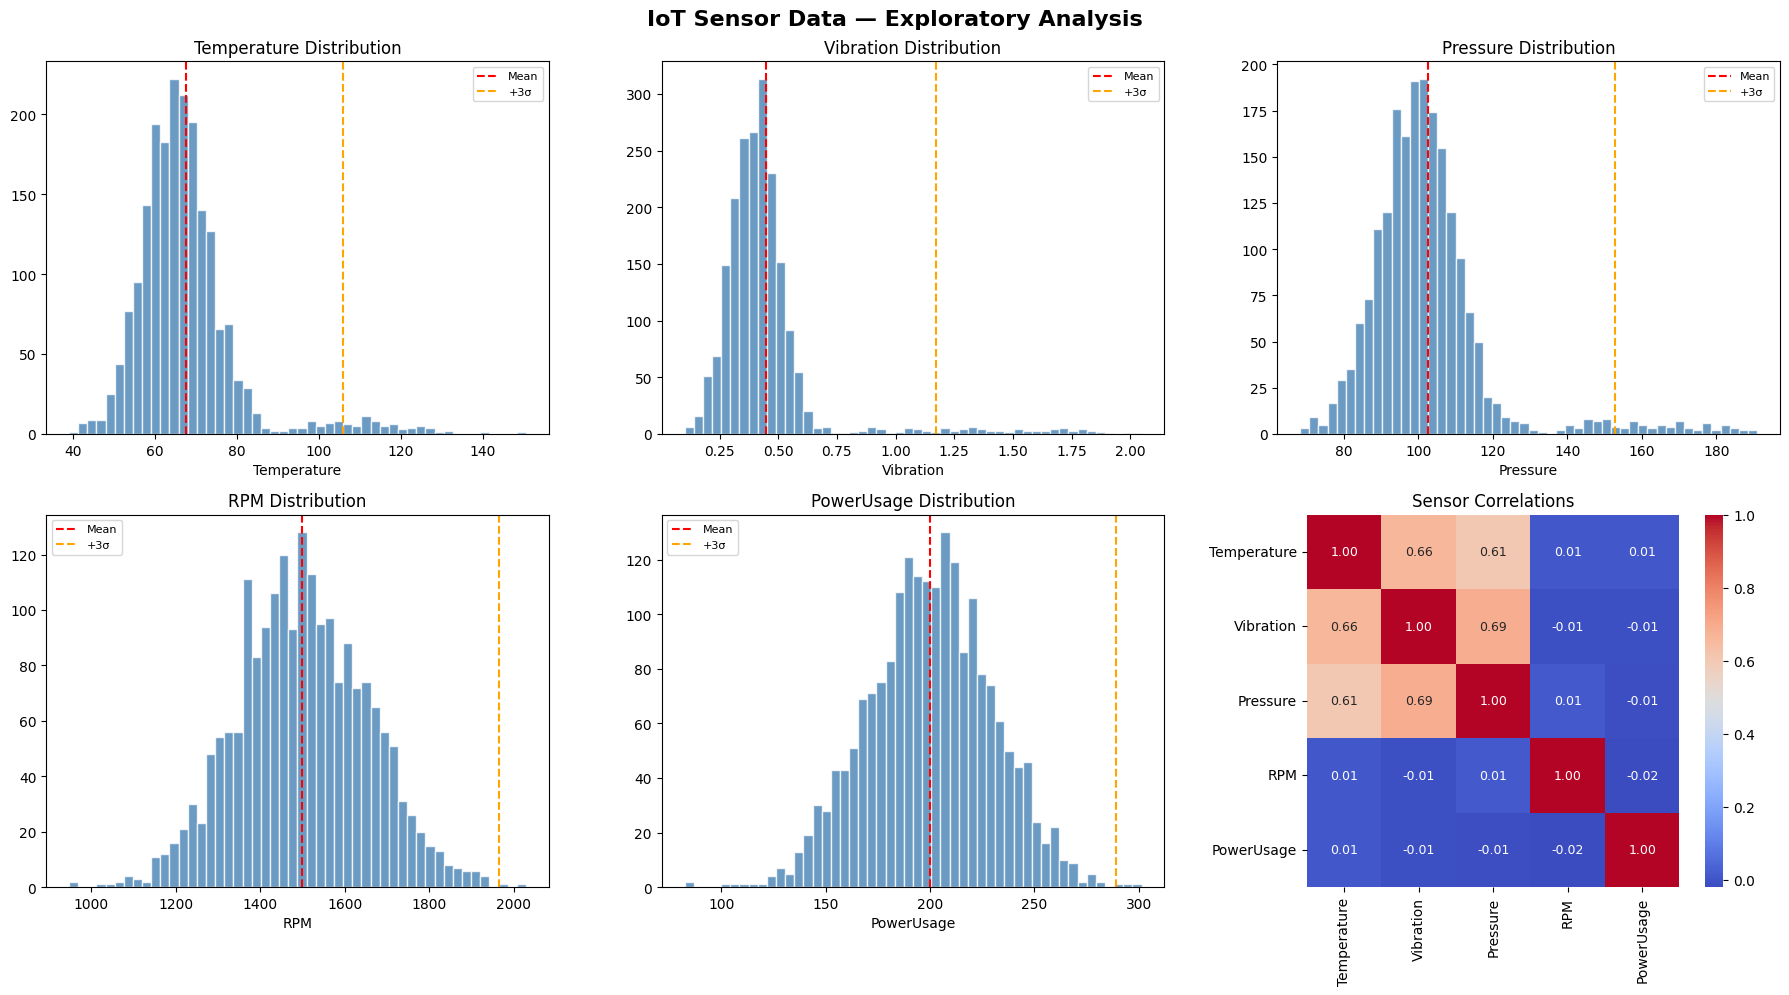

✅ EDA saved as sensor_eda.png


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = hdf.collect()
sensors = ['Temperature', 'Vibration', 'Pressure', 'RPM', 'PowerUsage']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('IoT Sensor Data — Exploratory Analysis', fontsize=16, fontweight='bold')

for idx, sensor in enumerate(sensors):
    ax = axes[idx // 3][idx % 3]
    ax.hist(df_plot[sensor], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(df_plot[sensor].mean(), color='red', linestyle='--', label='Mean')
    ax.axvline(df_plot[sensor].mean() + 3*df_plot[sensor].std(),
               color='orange', linestyle='--', label='+3σ')
    ax.set_title(f'{sensor} Distribution')
    ax.set_xlabel(sensor)
    ax.legend(fontsize=8)

# Correlation
corr = df_plot[sensors].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1][2], square=True, annot_kws={'size': 9})
axes[1][2].set_title('Sensor Correlations')

plt.tight_layout()
plt.savefig('sensor_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA saved as sensor_eda.png')

## 🤖 Step 5: KMeans Clustering — Machine Risk Groups

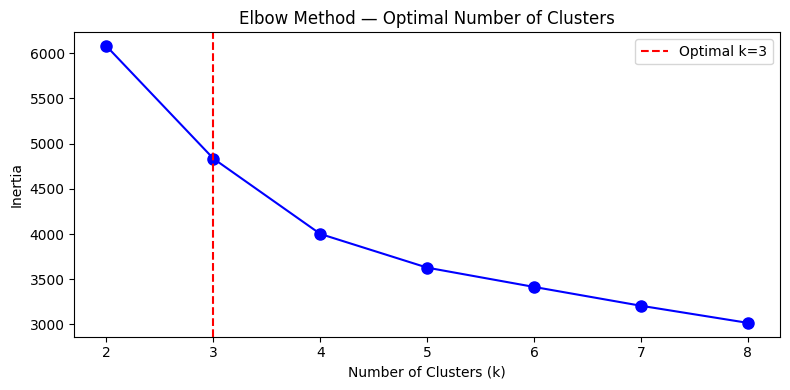

✅ Clustering complete!
RiskGroup
Low Risk       992
Medium Risk    908
High Risk      100


In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

FEATURES = ['Temperature', 'Vibration', 'Pressure', 'RPM', 'PowerUsage']
X = df_plot[FEATURES]

scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Find optimal k with Elbow Method
inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-', markersize=8)
plt.axvline(x=3, color='red', linestyle='--', label='Optimal k=3')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.legend()
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Train final model with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_plot['Cluster'] = kmeans.fit_predict(X_scaled)

# Label clusters by avg temperature (risk proxy)
cluster_temp = df_plot.groupby('Cluster')['Temperature'].mean().sort_values()
risk_map = {cluster_temp.index[0]: 'Low Risk',
            cluster_temp.index[1]: 'Medium Risk',
            cluster_temp.index[2]: 'High Risk'}
df_plot['RiskGroup'] = df_plot['Cluster'].map(risk_map)

print('✅ Clustering complete!')
print(df_plot['RiskGroup'].value_counts().to_string())

## 🚨 Step 6: Anomaly Detection

In [9]:
from sklearn.ensemble import IsolationForest
from scipy import stats

# Method 1: Isolation Forest
iso = IsolationForest(contamination=0.05, random_state=42)
df_plot['IsoForest_Anomaly'] = iso.fit_predict(X_scaled)
df_plot['IsoForest_Anomaly'] = df_plot['IsoForest_Anomaly'].map({1: 0, -1: 1})

# Method 2: Z-Score (flag if any sensor > 3 std devs)
z_scores = np.abs(stats.zscore(X))
df_plot['ZScore_Anomaly'] = (z_scores > 3).any(axis=1).astype(int)

# Combined: anomaly if flagged by BOTH methods
df_plot['Anomaly'] = ((df_plot['IsoForest_Anomaly'] == 1) &
                      (df_plot['ZScore_Anomaly'] == 1)).astype(int)

iso_count    = df_plot['IsoForest_Anomaly'].sum()
zscore_count = df_plot['ZScore_Anomaly'].sum()
combined     = df_plot['Anomaly'].sum()

print('=== Anomaly Detection Results ===')
print(f'   Isolation Forest : {iso_count} anomalies')
print(f'   Z-Score (>3σ)    : {zscore_count} anomalies')
print(f'   Combined         : {combined} confirmed anomalies')
print(f'   Anomaly Rate     : {combined/len(df_plot):.1%}')

=== Anomaly Detection Results ===
   Isolation Forest : 100 anomalies
   Z-Score (>3σ)    : 104 anomalies
   Combined         : 93 confirmed anomalies
   Anomaly Rate     : 4.7%


## 📈 Step 7: Visualize Clusters & Anomalies

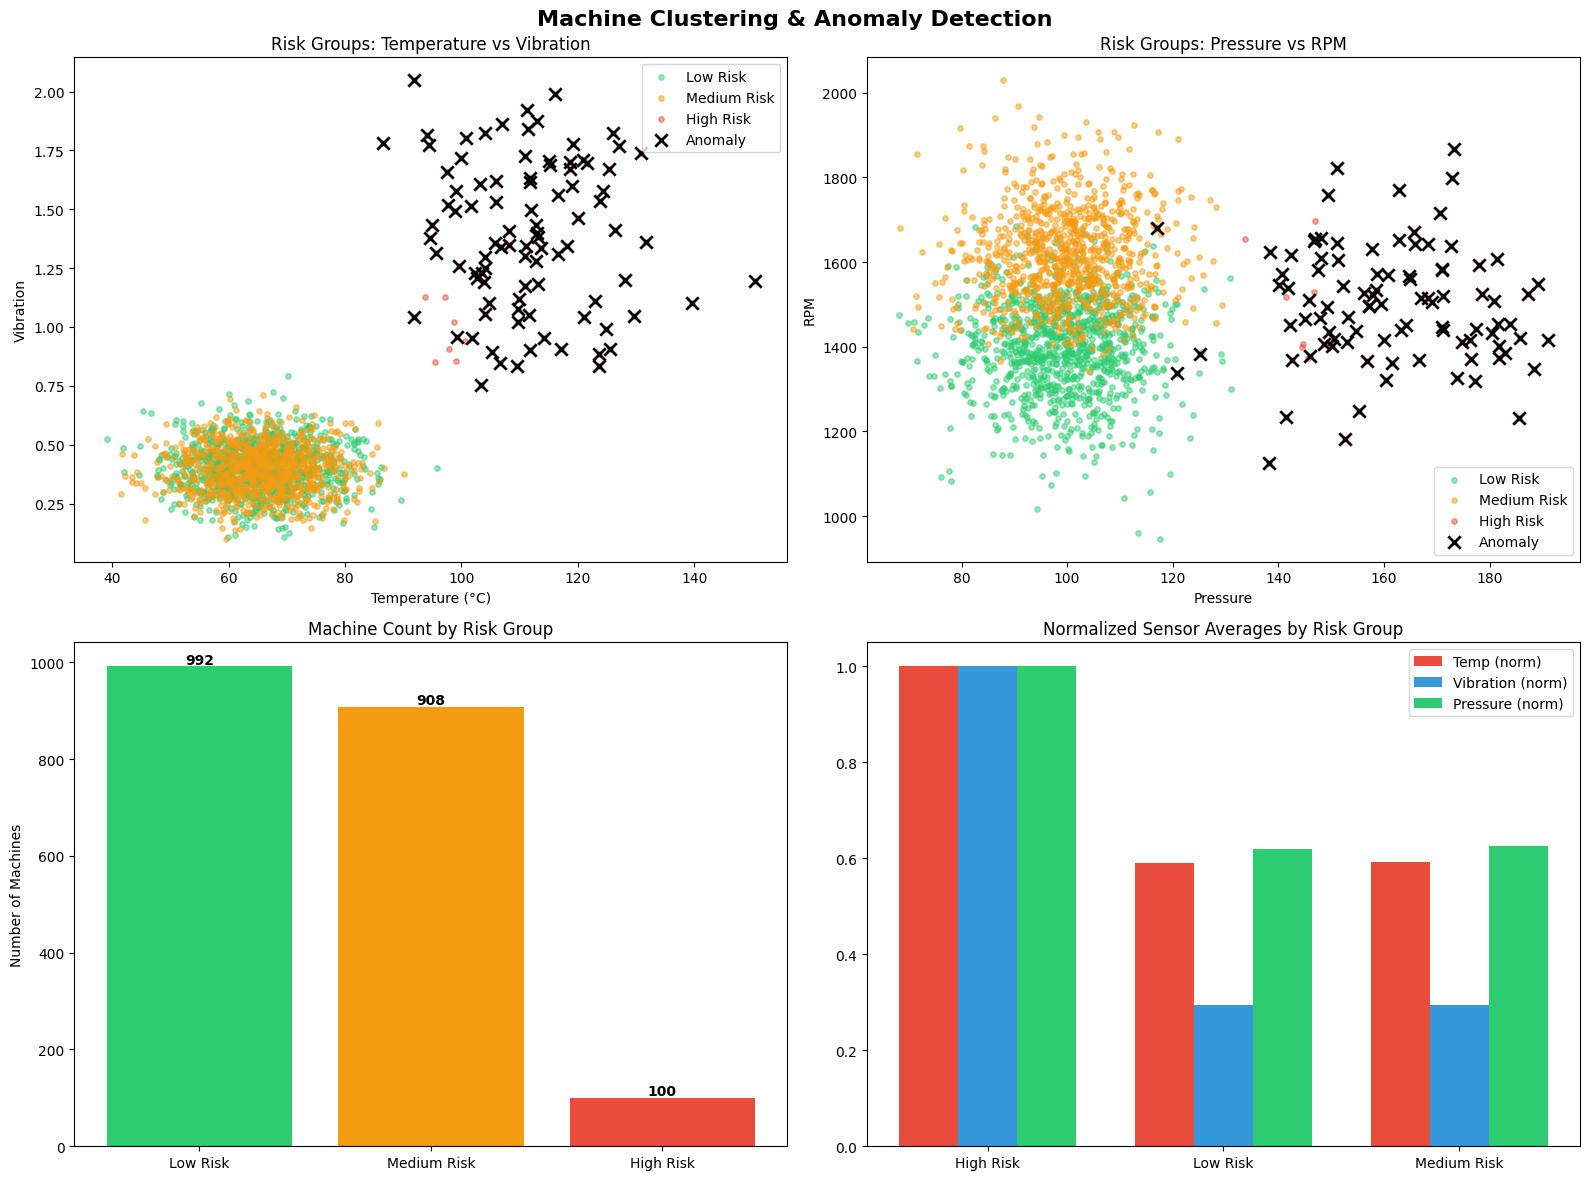

✅ Plots saved as clustering_results.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Machine Clustering & Anomaly Detection', fontsize=16, fontweight='bold')

risk_colors = {'Low Risk': '#2ecc71', 'Medium Risk': '#f39c12', 'High Risk': '#e74c3c'}

# 1. Temperature vs Vibration — colored by risk group
for group, color in risk_colors.items():
    mask = df_plot['RiskGroup'] == group
    axes[0,0].scatter(df_plot[mask]['Temperature'], df_plot[mask]['Vibration'],
                      c=color, label=group, alpha=0.5, s=15)
anomalies = df_plot[df_plot['Anomaly'] == 1]
axes[0,0].scatter(anomalies['Temperature'], anomalies['Vibration'],
                  c='black', marker='x', s=80, linewidths=2, label='Anomaly', zorder=5)
axes[0,0].set_xlabel('Temperature (°C)')
axes[0,0].set_ylabel('Vibration')
axes[0,0].set_title('Risk Groups: Temperature vs Vibration')
axes[0,0].legend()

# 2. Pressure vs RPM
for group, color in risk_colors.items():
    mask = df_plot['RiskGroup'] == group
    axes[0,1].scatter(df_plot[mask]['Pressure'], df_plot[mask]['RPM'],
                      c=color, label=group, alpha=0.5, s=15)
axes[0,1].scatter(anomalies['Pressure'], anomalies['RPM'],
                  c='black', marker='x', s=80, linewidths=2, label='Anomaly', zorder=5)
axes[0,1].set_xlabel('Pressure')
axes[0,1].set_ylabel('RPM')
axes[0,1].set_title('Risk Groups: Pressure vs RPM')
axes[0,1].legend()

# 3. Risk group distribution
risk_counts = df_plot['RiskGroup'].value_counts()
bars = axes[1,0].bar(risk_counts.index, risk_counts.values,
                      color=[risk_colors[r] for r in risk_counts.index])
axes[1,0].set_title('Machine Count by Risk Group')
axes[1,0].set_ylabel('Number of Machines')
for bar, val in zip(bars, risk_counts.values):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                   f'{val:,}', ha='center', fontweight='bold')

# 4. Cluster stats
cluster_stats = df_plot.groupby('RiskGroup')[['Temperature','Vibration','Pressure']].mean().round(2)
x_pos = np.arange(len(cluster_stats))
width = 0.25
axes[1,1].bar(x_pos - width, cluster_stats['Temperature']/cluster_stats['Temperature'].max(),
               width, label='Temp (norm)', color='#e74c3c')
axes[1,1].bar(x_pos,         cluster_stats['Vibration']/cluster_stats['Vibration'].max(),
               width, label='Vibration (norm)', color='#3498db')
axes[1,1].bar(x_pos + width, cluster_stats['Pressure']/cluster_stats['Pressure'].max(),
               width, label='Pressure (norm)', color='#2ecc71')
axes[1,1].set_xticks(x_pos)
axes[1,1].set_xticklabels(cluster_stats.index)
axes[1,1].set_title('Normalized Sensor Averages by Risk Group')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('clustering_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plots saved as clustering_results.png')

## 💾 Step 8: Save Results to SAP HANA

In [11]:
save_cols = ['MachineID','Temperature','Vibration','Pressure',
             'RPM','PowerUsage','OperatingHours','RiskGroup','Anomaly']

hdf_results = create_dataframe_from_pandas(
    connection_context=conn,
    pandas_df=df_plot[save_cols],
    table_name='machine_risk_results',
    schema=HANA_SCHEMA, force=True
)
print(f'✅ Results saved to HANA! Rows: {hdf_results.count():,}')

# Query anomalies from HANA
anomaly_query = conn.sql("""
    SELECT "MachineID", "Temperature", "Vibration",
           "Pressure", "RiskGroup", "Anomaly"
    FROM "ML_DEMO"."machine_risk_results"
    WHERE "Anomaly" = 1
    ORDER BY "Temperature" DESC
    LIMIT 10
""")
print('\n=== Top 10 Anomalous Machines (from HANA) ===')
print(anomaly_query.collect().to_string(index=False))

100%|██████████| 1/1 [00:00<00:00,  1.10it/s]


✅ Results saved to HANA! Rows: 2,000

=== Top 10 Anomalous Machines (from HANA) ===
MachineID  Temperature  Vibration  Pressure RiskGroup  Anomaly
   M_1616      150.448      1.197   120.831 High Risk        1
   M_0235      139.685      1.102   147.943 High Risk        1
   M_0826      131.734      1.362   174.825 High Risk        1
   M_1929      130.919      1.741   189.165 High Risk        1
   M_1002      129.681      1.045   141.513 High Risk        1
   M_0842      128.079      1.201   176.291 High Risk        1
   M_0283      127.066      1.769   172.613 High Risk        1
   M_1261      126.398      1.411   172.986 High Risk        1
   M_0178      126.058      1.826   177.295 High Risk        1
   M_0123      125.505      0.908   182.977 High Risk        1


## 📋 Step 9: Final Summary

In [12]:
print('=' * 55)
print('   🔍 CLUSTERING & ANOMALY DETECTION — SUMMARY')
print('=' * 55)
print(f'   Database     : SAP HANA Cloud')
print(f'   Machines     : {len(df_plot):,}')
print(f'   Features     : {FEATURES}')
print()
print('   Risk Groups (KMeans k=3):')
for group, count in df_plot["RiskGroup"].value_counts().items():
    pct = count/len(df_plot)*100
    icon = {'High Risk':'🔴','Medium Risk':'🟡','Low Risk':'🟢'}[group]
    print(f'   {icon} {group:<15}: {count:>4} machines ({pct:.1f}%)')
print()
print('   Anomaly Detection:')
print(f'   ⚠️  Isolation Forest : {iso_count} anomalies')
print(f'   ⚠️  Z-Score (>3σ)    : {zscore_count} anomalies')
print(f'   🚨 Confirmed         : {combined} anomalies ({combined/len(df_plot):.1%})')
print()
print('   Outputs saved to HANA:')
print('   ✅ ML_DEMO.machine_sensors      (raw data)')
print('   ✅ ML_DEMO.machine_risk_results (clusters + anomalies)')
print('=' * 55)
conn.close()
print('\n✅ Project complete!')

   🔍 CLUSTERING & ANOMALY DETECTION — SUMMARY
   Database     : SAP HANA Cloud
   Machines     : 2,000
   Features     : ['Temperature', 'Vibration', 'Pressure', 'RPM', 'PowerUsage']

   Risk Groups (KMeans k=3):
   🟢 Low Risk       :  992 machines (49.6%)
   🟡 Medium Risk    :  908 machines (45.4%)
   🔴 High Risk      :  100 machines (5.0%)

   Anomaly Detection:
   ⚠️  Isolation Forest : 100 anomalies
   ⚠️  Z-Score (>3σ)    : 104 anomalies
   🚨 Confirmed         : 93 anomalies (4.7%)

   Outputs saved to HANA:
   ✅ ML_DEMO.machine_sensors      (raw data)
   ✅ ML_DEMO.machine_risk_results (clusters + anomalies)

✅ Project complete!
